In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries loaded")

Libraries loaded


In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


# Daily Return Analysis

Daily returns are computed using:

daily_return = NAV(t) / NAV(t−1) − 1

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


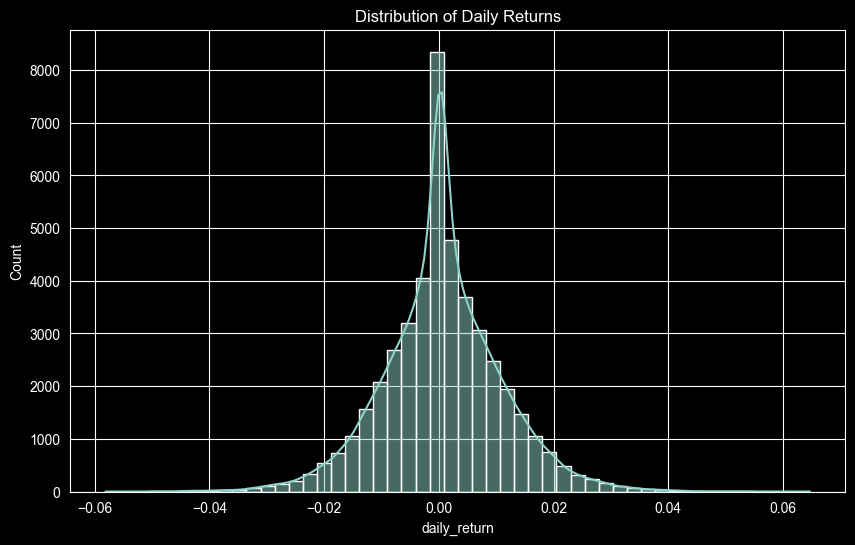

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

### Insight

Most daily returns cluster near zero with relatively few extreme movements, indicating a generally stable return distribution.

In [5]:
nav.to_csv(
    "../data/processed/nav_daily_returns.csv",
    index=False
)

print("Saved")

Saved


# CAGR Analysis

CAGR (Compound Annual Growth Rate) measures the annualized growth rate of a fund over a specified period.

Formula:

CAGR = (Ending NAV / Starting NAV)^(1/n) - 1

In [6]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund]

    fund_data = fund_data.sort_values("date")

    if len(fund_data) < 2:
        continue

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365.25

    if years <= 0:
        continue

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append([
        fund,
        round(cagr * 100, 2)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [7]:
cagr_df.to_csv(
    "../data/processed/fund_cagr.csv",
    index=False
)

print("CAGR table saved")

CAGR table saved


# Sharpe Ratio

Sharpe Ratio measures risk-adjusted returns.

Risk Free Rate (Rf) = 6.5%

In [8]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(returns) < 10:
        continue

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - rf)
        / annual_volatility
    )

    sharpe_results.append([
        fund,
        round(sharpe, 3)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448
30,120843,1.307
36,148569,1.235
19,119551,1.208
25,120505,1.180


In [9]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe ratio table saved")

Sharpe ratio table saved


# Sortino Ratio

Sortino Ratio measures risk-adjusted returns using only downside volatility.

Unlike Sharpe Ratio, it penalizes only negative return days.

In [10]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(returns) < 10:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    if downside_std == 0:
        continue

    sortino = (
        (annual_return - rf)
        / downside_std
    )

    sortino_results.append([
        fund,
        round(sortino, 3)
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.386
30,120843,2.364
36,148569,2.147
19,119551,2.140
25,120505,2.029


In [13]:
import pandas as pd

nav_data = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav_data["date"] = pd.to_datetime(
    nav_data["date"]
)

nav_data.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [14]:
import pandas as pd
from scipy.stats import linregress

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

benchmark = benchmark.sort_values(
    "date"
)

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

alpha_beta_results = []

for amfi in nav_data["amfi_code"].unique():

    fund = nav_data[
        nav_data["amfi_code"] == amfi
    ].copy()

    fund = fund.sort_values("date")

    fund["fund_return"] = (
        fund["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund[["date", "fund_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        alpha_beta_results.append([
            amfi,
            intercept * 252,
            slope
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,119551,0.232010,-0.031751
1,119552,0.198686,-0.026159
2,119598,0.303370,-0.023196
3,119599,0.048824,0.062002
4,119120,0.056209,-0.006414


In [15]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


## Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline from a fund's peak NAV to its lowest point before recovery.

Lower drawdowns indicate better downside protection and lower risk during market corrections.

In [18]:
drawdown_results = []

for amfi in nav_data["amfi_code"].unique():

    fund = nav_data[
        nav_data["amfi_code"] == amfi
    ].copy()

    fund = fund.sort_values("date")

    fund["running_max"] = (
        fund["nav"].cummax()
    )

    fund["drawdown"] = (
        fund["nav"] /
        fund["running_max"] - 1
    )

    max_dd = fund["drawdown"].min()

    drawdown_results.append(
        [amfi, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
3,119599,-0.525742
27,119095,-0.516778
29,101207,-0.354469
39,149324,-0.311719
2,119598,-0.287060


In [19]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


## Fund Scorecard

A composite score is created to rank funds based on return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection.

Scoring Weights:

- 30% → 3-Year Return Rank
- 25% → Sharpe Ratio Rank
- 20% → Alpha Rank
- 15% → Expense Ratio Rank (Inverse)
- 10% → Maximum Drawdown Rank (Inverse)

In [28]:
scorecard = performance_data.copy()

In [29]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

In [30]:
scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_ratio_y'],
      dtype='str')

In [31]:
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_y"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=True)
)

In [32]:
scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

In [33]:
scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head(10)

,amfi_code,scheme_name,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,9.900
26,119094,Axis Midcap Fund - Regular - Growth,13.300
12,120505,ICICI Pru Midcap Fund - Regular - Growth,13.600
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,13.800
2,119598,SBI Small Cap Fund - Regular Plan - Growth,14.250
29,101207,ABSL Small Cap Fund - Regular - Growth,14.575
3,119599,SBI Small Cap Fund - Direct Plan - Growth,15.025
38,149323,DSP Midcap Fund - Regular - Growth,15.600
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.600
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,15.725


In [34]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


## Benchmark Comparison – Top 5 Funds vs NIFTY50
Comparing fund performance against benchmark index.
Tracking Error measures deviation from benchmark returns.

In [35]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [36]:
benchmark["daily_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

In [37]:
top5 = scorecard.head(5)

top5[[
    "amfi_code",
    "scheme_name"
]]

,amfi_code,scheme_name
22,120843,Kotak Flexicap Fund - Regular - Growth
26,119094,Axis Midcap Fund - Regular - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth


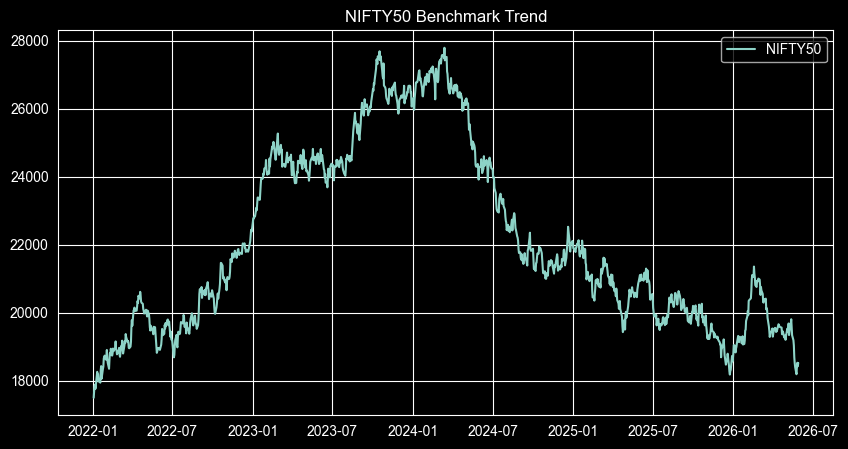

In [38]:
import matplotlib.pyplot as plt

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

plt.figure(figsize=(10,5))

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    label="NIFTY50"
)

plt.title(
    "NIFTY50 Benchmark Trend"
)

plt.legend()
plt.show()

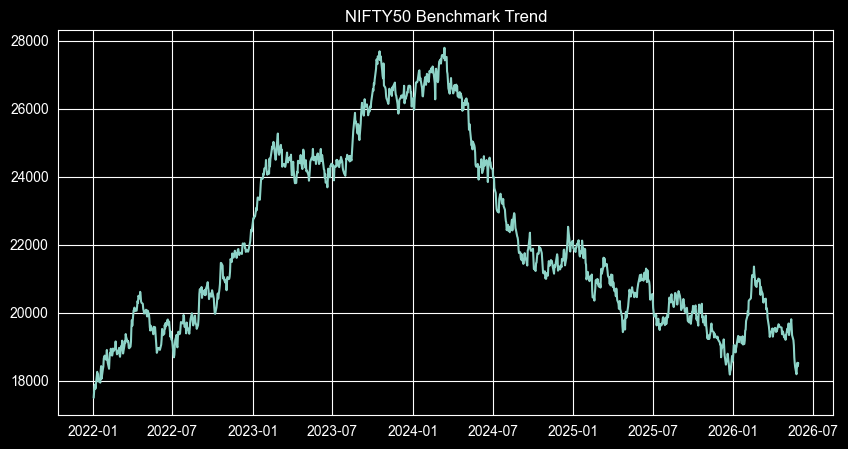

Chart saved


In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    nifty50["date"],
    nifty50["close_value"]
)

plt.title("NIFTY50 Benchmark Trend")

plt.savefig(
    "../reports/benchmark_comparison_chart.png"
)

plt.show()

print("Chart saved")